# 术语和评价指标

* AUC（Area Under Curve）   
  AUC（Area Under Curve）是机器学习和统计学中常用的一个评价指标，用于评估分类模型的性能。   
  具体来说，AUC是指ROC曲线下的面积，其中ROC（Receiver Operating Characteristic）曲线是一种以假正类率（False Positive Rate, FPR）为横轴、真正类率（True Positive Rate, TPR）为纵轴绘制的图形。   
  真正类率（TPR, True Positive Rate）：也称为敏感度（Sensitivity），表示模型正确预测为正类的比例。$TPR=\frac{TP}{TP+FN}$, 其中，TP是真正例数，FN是假负例数。   
  假正类率（FPR, False Positive Rate）：表示模型错误地将负类预测为正类的比例。FPR=FP/(FP+TN)，其中，FP是假正例数，TN是真负例数。   
  ROC曲线：通过改变分类阈值，计算不同阈值下的TPR和FPR，并将这些点连接起来形成的一条曲线。   
  AUC值：ROC曲线下的面积，取值范围为[0, 1]。AUC值越大，说明模型的区分能力越强。   

1、混淆矩阵（Confuse Matrix）   

（1）若一个实例是正类，并且被预测为正类，即为真正类TP(True Positive )   
（2）若一个实例是正类，但是被预测为负类，即为假负类FN(False Negative )   
（3）若一个实例是负类，但是被预测为正类，即为假正类FP(False Positive )   
（4）若一个实例是负类，并且被预测为负类，即为真负类TN(True Negative )   
2、准确率（Accuracy） 准确率是常用的一个评价指标，但是不适合样本不均衡的情况。   
$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$   
 

3、精确率（Precision） 又称查准率，正确预测为正样本（TP）占预测为正样本(TP+FP)的百分比。   
$Precision=\frac{TP}{TP+FP}$    

4、召回率（Recall） 又称为查全率，正确预测为正样本（TP）占正样本(TP+FN)的百分比。   
$Recall=\frac{TP}{TP+FN}$   

5、F1 Score 精确率和召回率是相互影响的，精确率升高则召回率下降，召回率升高则精确率下降，如果需要兼顾二者，就需要精确率、召回率的结合F1 Score。   
$F1−Score=\frac{2}{\frac{1}{Precision}+\frac{1}{Recall}}$   
 

6、P-R曲线（Precision-Recall Curve） P-R曲线是描述精确率和召回率变化的曲线   
7、ROC（Receiver Operating Characteristic）：一种以假正类率（False Positive Rate, FPR）为横轴、真正类率（True Positive Rate, TPR）为纵轴绘制的图形。   
8、AUC(Area Under Curve) AUC（Area Under Curve）被定义为 ROC曲线 下与坐标轴围成的面积，显然这个面积的数值不会大于1。又由于ROC曲线一般都处于y=x这条直线的上方，所以AUC的取值范围在0.5和1之间。AUC越接近1.0，检测方法真实性越高;等于0.5时，则真实性最低，无应用价值。   

## 对于金融风控预测类常见的评估指标如下:   
1、KS(Kolmogorov-Smirnov) KS统计量由两位苏联数学家A.N. Kolmogorov和N.V. Smirnov提出。在风控中，KS常用于评估模型区分度。区分度越大，说明模型的风险排序能力（ranking ability）越强。 K-S曲线与ROC曲线类似，不同在于   

ROC曲线将真正例率和假正例率作为横纵轴   
K-S曲线将真正例率和假正例率都作为纵轴，横轴则由选定的阈值来充当。 公式如下：   
$KS=max(TPR−FPR)$
 
KS不同代表的不同情况，一般情况KS值越大，模型的区分能力越强，但是也不是越大模型效果就越好，如果KS过大，模型可能存在异常，所以当KS值过高可能需要检查模型是否过拟合。以下为KS值对应的模型情况，但此对应不是唯一的，只代表大致趋势。   
KS（%）	好坏区分能力   
20以下	不建议采用   
20-40	较好   
41-50	良好   
51-60	很强   
61-75	非常强   
75以上	过于高，疑似存在问题  

2、ROC

3、AUC

In [ ]:
#下载数据
import pandas as pd
# 下载测试数据集 41.33mb
!wget http://tianchi-media.oss-cn-beijing.aliyuncs.com/dragonball/FRC/data_set/testA.csv
# 下载训练数据集 166.77mb
!wget http://tianchi-media.oss-cn-beijing.aliyuncs.com/dragonball/FRC/data_set/train.csv

Train data shape: (800000, 47)
TestA data shape: (200000, 46)
Index(['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'grade',
       'subGrade', 'employmentTitle', 'employmentLength', 'homeOwnership',
       'annualIncome', 'verificationStatus', 'issueDate', 'isDefault',
       'purpose', 'postCode', 'regionCode', 'dti', 'delinquency_2years',
       'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec',
       'pubRecBankruptcies', 'revolBal', 'revolUtil', 'totalAcc',
       'initialListStatus', 'applicationType', 'earliesCreditLine', 'title',
       'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8',
       'n9', 'n10', 'n11', 'n12', 'n13', 'n14'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 47 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  800000 non-null  int64  
 1   loanAmnt            800000 non

<Axes: >

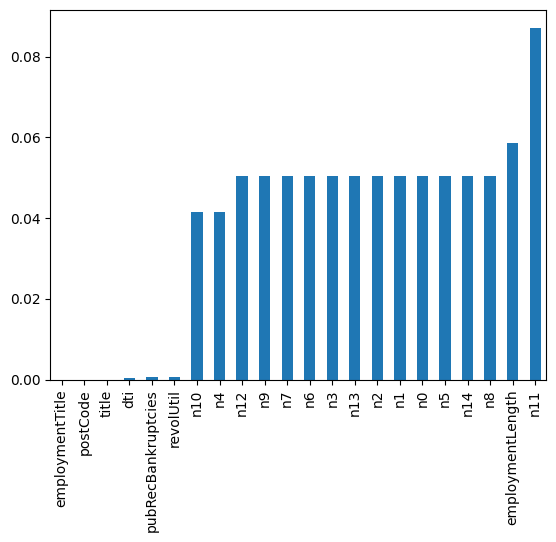

In [39]:
#数据读取
import pandas as pd
train = pd.read_csv('train.csv')
testA = pd.read_csv('testA.csv')
print('Train data shape:',train.shape)
print('TestA data shape:',testA.shape)

print(train.columns)

train.head()
train.info()
train.describe()
print(f"Columns with null values:{train.isnull().any().sum()}")
print(train.isnull().sum())

# nan可视化
missing = train.isnull().sum()/len(train)
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()


In [ ]:
#分欸指标评价计算
## 混淆矩阵
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred = [0, 1, 0, 1]
y_true = [0, 1, 1, 0]
print('混淆矩阵:\n',confusion_matrix(y_true, y_pred))

## accuracy
from sklearn.metrics import accuracy_score
y_pred = [0, 1, 0, 1]
y_true = [0, 1, 1, 0]
print('ACC:',accuracy_score(y_true, y_pred))

## Precision,Recall,F1-score
from sklearn import metrics
y_pred = [0, 1, 0, 1]
y_true = [0, 1, 1, 0]
print('Precision',metrics.precision_score(y_true, y_pred))
print('Recall',metrics.recall_score(y_true, y_pred))
print('F1-score:',metrics.f1_score(y_true, y_pred))

## P-R曲线
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
y_pred = [0, 1, 1, 0, 1, 1, 0, 1, 1, 1]
y_true = [0, 1, 1, 0, 1, 0, 1, 1, 0, 1]
precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
plt.plot(precision, recall)
plt.show()

## ROC曲线
from sklearn.metrics import roc_curve
y_pred = [0, 1, 1, 0, 1, 1, 0, 1, 1, 1]
y_true = [0, 1, 1, 0, 1, 0, 1, 1, 0, 1]
FPR,TPR,thresholds=roc_curve(y_true, y_pred)
plt.title('ROC')
plt.plot(FPR, TPR,'b')
plt.plot([0,1],[0,1],'r--')
plt.ylabel('TPR')
plt.xlabel('FPR')

## AUC
import numpy as np
from sklearn.metrics import roc_auc_score
y_true = np.array([0, 0, 1, 1])
y_scores = np.array([0.1, 0.4, 0.35, 0.8])
print('AUC socre:',roc_auc_score(y_true, y_scores))

## KS值 在实际操作时往往使用ROC曲线配合求出KS值
from sklearn.metrics import roc_curve
y_pred = [0, 1, 1, 0, 1, 1, 0, 1, 1, 1]
y_true = [0, 1, 1, 0, 1, 0, 1, 1, 1, 1]
FPR,TPR,thresholds=roc_curve(y_true, y_pred)
KS=abs(FPR-TPR).max()
print('KS值：',KS)

#评分卡 不是标准评分卡
def Score(prob,P0=600,PDO=20,badrate=None,goodrate=None):
    P0 = P0
    PDO = PDO
    theta0 = badrate/goodrate
    B = PDO/np.log(2)
    A = P0 + B*np.log(2*theta0)
    score = A-B*np.log(prob/(1-prob))
    return score

In [ ]:
#用 pandas_profiling 生成数据报告 
#import pandas_profiling  #依赖 numba 0.54之前的版本，之后的版本移除了 generated_jit，这个是 pandas_profiling 所依赖的
from ydata_profiling import ProfileReport
pfr = ProfileReport(train)
#pfr.to_file("./example.html")

In [ ]:
print(train['term'].value_counts())#离散型变量
#每个数字特征得分布可视化
# 这里画图估计需要10-15分钟
import seaborn as sns
numerical_fea = list(train.select_dtypes(exclude=['object']).columns)
#过滤数值型类别特征
def get_numerical_serial_fea(data,feas):
    numerical_serial_fea = []
    numerical_noserial_fea = []
    for fea in feas:
        temp = data[fea].nunique()
        if temp <= 10:
            numerical_noserial_fea.append(fea)
            continue
        numerical_serial_fea.append(fea)
    return numerical_serial_fea,numerical_noserial_fea
numerical_serial_fea,numerical_noserial_fea = get_numerical_serial_fea(train,numerical_fea)
f = pd.melt(train, value_vars=numerical_serial_fea)
g = sns.FacetGrid(f, col="variable",  col_wrap=2, sharex=False, sharey=False)
g = g.map(sns.distplot, "value")

In [ ]:
#Ploting Transaction Amount Values Distribution
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(16,12))
plt.suptitle('Transaction Values Distribution', fontsize=22)
plt.subplot(221)
sub_plot_1 = sns.distplot(train['loanAmnt'])
sub_plot_1.set_title("loanAmnt Distribuition", fontsize=18)
sub_plot_1.set_xlabel("")
sub_plot_1.set_ylabel("Probability", fontsize=15)

plt.subplot(222)
sub_plot_2 = sns.distplot(np.log(train['loanAmnt']))
sub_plot_2.set_title("loanAmnt (Log) Distribuition", fontsize=18)
sub_plot_2.set_xlabel("")
sub_plot_2.set_ylabel("Probability", fontsize=15)

In [ ]:
#单一变量分布可视化

plt.figure(figsize=(8, 8))
value_counts = train["employmentLength"].value_counts(dropna=False)[:20]
print(value_counts)
sns.barplot(x=value_counts.values,
            y=value_counts.index)
plt.show()

In [ ]:
#查看类别型变量在不同y值上的分布
train_loan_fr = train.loc[train['isDefault'] == 1]
train_loan_nofr = train.loc[train['isDefault'] == 0]
print(train_loan_fr)
print(train_loan_nofr)

import matplotlib.pyplot as plt
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))
train_loan_fr.groupby('grade')['grade'].count().plot(kind='barh', ax=ax1, title='Count of grade fraud')
train_loan_nofr.groupby('grade')['grade'].count().plot(kind='barh', ax=ax2, title='Count of grade non-fraud')
train_loan_fr.groupby('employmentLength')['employmentLength'].count().plot(kind='barh', ax=ax3, title='Count of employmentLength fraud')
train_loan_nofr.groupby('employmentLength')['employmentLength'].count().plot(kind='barh', ax=ax4, title='Count of employmentLength non-fraud')
plt.show()

#查看连续型变量在不同y值上的分布
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 6))
train.loc[train['isDefault'] == 1] \
    ['loanAmnt'].apply(np.log) \
    .plot(kind='hist',
          bins=100,
          title='Log Loan Amt - Fraud',
          color='r',
          xlim=(-3, 10),
         ax= ax1)
train.loc[train['isDefault'] == 0] \
    ['loanAmnt'].apply(np.log) \
    .plot(kind='hist',
          bins=100,
          title='Log Loan Amt - Not Fraud',
          color='b',
          xlim=(-3, 10),
         ax=ax2)
plt.show()

data_train = train
total = len(data_train)
total_amt = data_train.groupby(['isDefault'])['loanAmnt'].sum().sum()
plt.figure(figsize=(12,5))
plt.subplot(121)##1代表行，2代表列，所以一共有2个图，1代表此时绘制第一个图。
plot_tr = sns.countplot(x='isDefault',data=data_train)#data_train‘isDefault’这个特征每种类别的数量**
plot_tr.set_title("Fraud Loan Distribution \n 0: good user | 1: bad user", fontsize=14)
plot_tr.set_xlabel("Is fraud by count", fontsize=16)
plot_tr.set_ylabel('Count', fontsize=16)
for p in plot_tr.patches:
    height = p.get_height()
    plot_tr.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=15) 
    
percent_amt = (data_train.groupby(['isDefault'])['loanAmnt'].sum())
percent_amt = percent_amt.reset_index()
plt.subplot(122)
plot_tr_2 = sns.barplot(x='isDefault', y='loanAmnt',  dodge=True, data=percent_amt)
plot_tr_2.set_title("Total Amount in loanAmnt  \n 0: good user | 1: bad user", fontsize=14)
plot_tr_2.set_xlabel("Is fraud by percent", fontsize=16)
plot_tr_2.set_ylabel('Total Loan Amount Scalar', fontsize=16)
for p in plot_tr_2.patches:
    height = p.get_height()
    plot_tr_2.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total_amt * 100),
            ha="center", fontsize=15)  

plt.show()

import datetime
#转化成时间格式  issueDateDT特征表示数据日期离数据集中日期最早的日期（2007-06-01）的天数
data_train['issueDate'] = pd.to_datetime(data_train['issueDate'],format='%Y-%m-%d')
startdate = datetime.datetime.strptime('2007-06-01', '%Y-%m-%d')
data_train['issueDateDT'] = data_train['issueDate'].apply(lambda x: x-startdate).dt.days
#透视图 索引可以有多个，“columns（列）”是可选的，聚合函数aggfunc最后是被应用到了变量“values”中你所列举的项目上。
pivot = pd.pivot_table(data_train, index=['grade'], columns=['issueDateDT'], values=['loanAmnt'], aggfunc=np.sum)
pivot

## 数据分桶
特征分箱的目的：   
从模型效果上来看，特征分箱主要是为了降低变量的复杂性，减少变量噪音对模型的影响，提高自变量和因变量的相关度。从而使模型更加稳定。   
数据分桶的对象：   
将连续变量离散化   
将多状态的离散变量合并成少状态   
分箱的原因：   
数据的特征内的值跨度可能比较大，对有监督和无监督中如k-均值聚类它使用欧氏距离作为相似度函数来测量数据点之间的相似度。都会造成大吃小的影响，其中一种解决方法是对计数值进行区间量化即数据分桶也叫做数据分箱，然后使用量化后的结果。   
分箱的优点：   

处理缺失值：当数据源可能存在缺失值，此时可以把null单独作为一个分箱。   
处理异常值：当数据中存在离群点时，可以把其通过分箱离散化处理，从而提高变量的鲁棒性（抗干扰能力）。例如，age若出现200这种异常值，可分入“age > 60”这个分箱里，排除影响。   
业务解释性：我们习惯于线性判断变量的作用，当x越来越大，y就越来越大。但实际x与y之间经常存在着非线性关系，此时可经过WOE变换。   
特别要注意一下分箱的基本原则：   

（1）最小分箱占比不低于5%   
（2）箱内不能全部是好客户   
（3）连续箱单调   
固定宽度分箱   

当数值横跨多个数量级时，最好按照 10 的幂（或任何常数的幂）来进行分组：0~9、10~99、100~999、1000~9999，等等。固定宽度分箱非常容易计算，但如果计数值中有比较大的缺口，就会产生很多没有任何数据的空箱子。   

In [44]:
# 通过除法映射到间隔均匀的分箱中，每个分箱的取值范围都是loanAmnt/1000
train['loanAmnt_bin1'] = np.floor_divide(train['loanAmnt'], 1000)
print(train['loanAmnt_bin1'])

## 通过对数函数映射到指数宽度分箱
train['loanAmnt_bin2'] = np.floor(np.log10(train['loanAmnt']))
print(train['loanAmnt_bin2'])

#分位数分箱
train['loanAmnt_bin3'] = pd.qcut(train['loanAmnt'], 10, labels=False)
print(train['loanAmnt_bin3'])

0         35.0
1         18.0
2         12.0
3         11.0
4          3.0
          ... 
799995    25.0
799996    17.0
799997     6.0
799998    19.0
799999     9.0
Name: loanAmnt_bin1, Length: 800000, dtype: float64
0         4.0
1         4.0
2         4.0
3         4.0
4         3.0
         ... 
799995    4.0
799996    4.0
799997    3.0
799998    4.0
799999    3.0
Name: loanAmnt_bin2, Length: 800000, dtype: float64
0         9
1         6
2         4
3         4
4         0
         ..
799995    8
799996    6
799997    1
799998    7
799999    3
Name: loanAmnt_bin3, Length: 800000, dtype: int64


# 特征交互
交互特征的构造非常简单，使用起来却代价不菲。如果线性模型中包含有交互特征对，那它的训练时间和评分时间就会从 O(n) 增加到 O(n2)，其中 n 是单一特征的数量。

# 模型调参
**贪心调参**

先使用当前对模型影响最大的参数进行调优，达到当前参数下的模型最优化，再使用对模型影响次之的参数进行调优，如此下去，直到所有的参数调整完毕。

这个方法的缺点就是可能会调到局部最优而不是全局最优，但是只需要一步一步的进行参数最优化调试即可，容易理解。

需要注意的是在树模型中参数调整的顺序，也就是各个参数对模型的影响程度

**网格搜索**
sklearn 提供GridSearchCV用于进行网格搜索，只需要把模型的参数输进去，就能给出最优化的结果和参数。相比起贪心调参，网格搜索的结果会更优，但是网格搜索只适合于小数据集，一旦数据的量级上去了，很难得出结果。

**贝叶斯调参**
使用之前需要先安装包bayesian-optimization，运行如下命令即可：

pip install bayesian-optimization
贝叶斯调参的主要思想是：给定优化的目标函数(广义的函数，只需指定输入和输出即可，无需知道内部结构以及数学性质)，通过不断地添加样本点来更新目标函数的后验分布(高斯过程,直到后验分布基本贴合于真实分布）。简单的说，就是考虑了上一次参数的信息，从而更好的调整当前的参数。

贝叶斯调参的步骤如下：

定义优化函数(rf_cv）
建立模型
定义待优化的参数
得到优化结果，并返回要优化的分数指标
from sklearn.model_selection import cross_val_score